This example shows how to visualize concentrations for hillslope model case_cybernetic run1
- domain average - time plot
    - subsurface domain average
    - surface domain average
- column average - time plot
- soil-layer average - time plot
- tested under ats version 1.5

In [1]:
import ats_xdmf as xdmf # $ATS_SRC_DIR/tools/utils/ats_xdmf.py

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import h5py

model_dir = "./NF01"
cv_key = 'surface-cell_volume'

generate_plots = False
generate_animation = False

# Load data
## load observation files

This will load the `water_balance.dat` file generated from ATS model. The data file includes watershed variables including outlet discharge, ET, and etc. By default, setting `plot=True` will show the water balance plots for `global, canopy, snow, surface, and subsurface` domains. **It is important to check if `max error` is close to zero!** Otherwise, there may be a water balance issue in the model.

In [3]:
data_file_wb = os.path.join(model_dir, 'water_balance.dat')
data_wb = pd.read_csv(data_file_wb, comment='#')

In [4]:
data_wb
# {right, left, bottom, top, front, back} face flux all have the same unit [mol d^-1]

,time [d],surface water content [mol],subsurface water content [mol],snow water content [mol],canopy water content [mol],runoff generation [mol per time interval],evapotranspiration [m per time interval],snow precipitation [m per time interval],rain precipitation [m per time interval],canopy evaporation [m per time interval],...,exfiltration [mol per time interval],surface right boundary [mol per time interval],surface left boundary [mol per time interval],right face flux [mol per time interval],left face flux [mol per time interval],bottom face flux [mol per time interval],top face flux [mol per time interval],top face flux 2 [mol per time interval],front face flux [mol per time interval],back face flux [mol per time interval]
0,0.0,92442.082846,8.290603e+07,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00
1,1.0,93222.075097,8.290816e+07,0.000000e+00,0.000000,15748.216319,0.000065,0.000000,0.0,0.000000e+00,...,18968.613455,15748.216319,0.0,49622.299852,-70717.338003,1.176494e-09,18971.307543,18971.307543,-3.937321e-08,-3.937321e-08
2,2.0,93406.832848,8.290977e+07,0.000000e+00,0.000000,16743.145164,0.000067,0.000000,0.0,0.000000e+00,...,19430.484152,16743.145164,0.0,49876.684087,-70921.439701,2.504359e-09,19430.921651,19430.921651,4.424543e-07,4.424543e-07
3,3.0,93464.600989,8.291169e+07,0.000000e+00,0.000000,17039.082620,0.000067,0.000000,0.0,0.000000e+00,...,19598.585671,17039.082620,0.0,50053.868993,-71579.107510,6.408712e-08,19599.796285,19599.796285,-1.740049e-06,-1.740049e-06
4,4.0,93500.526127,8.291428e+07,5.906608e+04,2250.886451,17253.912813,0.000063,0.001648,0.0,0.000000e+00,...,19360.696890,17253.912813,0.0,50157.835412,-72109.096298,2.481861e-08,19361.382646,19361.382646,8.389173e-07,8.389173e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,413.0,71222.264489,8.252764e+07,5.010999e+06,1476.005058,13797.022912,0.000050,0.000000,0.0,9.856365e-09,...,13319.640688,13797.022912,0.0,42388.038425,-72569.902500,-2.291764e-11,13319.574322,13319.574322,-1.445968e-09,-1.445968e-09
414,414.0,70759.854887,8.254478e+07,5.009391e+06,1436.162461,13738.221283,0.000055,0.000000,0.0,7.197132e-08,...,13275.811682,13738.221283,0.0,42402.053438,-72815.694878,1.128384e-11,13275.884691,13275.884691,5.131322e-09,5.131322e-09
415,415.0,69529.368924,8.256181e+07,5.007784e+06,1420.662792,14686.031285,0.000057,0.000000,0.0,2.533493e-07,...,13455.545322,14686.031285,0.0,42473.131496,-72969.434786,-1.604979e-09,13455.654652,13455.654652,-2.496604e-07,-2.496604e-07
416,416.0,68885.658026,8.257888e+07,5.006177e+06,1391.221506,14069.291550,0.000054,0.000000,0.0,6.793786e-07,...,13425.580654,14069.291550,0.0,42527.728729,-73033.846262,-3.462602e-10,13425.548912,13425.548912,1.323144e-08,1.323144e-08


In [5]:
# the goal of vis/obs_file_time_interval here is to make comparable plot
# between results from different time interval setting
#vis_file_time_interval = 1.0 # unit is day. convert the unit if in xml it's not configured as day
#obs_file_time_interval = 1.0

# automatically determine time_interval from data_wb['time [d]']

time_days = data_wb['time [d]']
time4plot = time_days[1:]

obs_file_time_interval_vec = np.diff(time_days)

vis_file_time_interval_vec = obs_file_time_interval_vec

print(obs_file_time_interval_vec)
print(len(obs_file_time_interval_vec))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

In [6]:
# convert precipitation unit
# water_density = 1000  # kg/m³
# water_molar_mass = 0.018  # kg/mol
rho_m1 = 55500. # moles/m^3, water molar density
rho_m2 = 55000.
surface_area1 = 680 * 1  # m²; y=1 is determined in m2 = watershed_workflow.mesh.Mesh2D.from_Transect(x,z)
s_per_d = 86400

with h5py.File(os.path.join(model_dir, 'ats_vis_surface_data.h5'),'r') as d:
    a_key = list(d[cv_key].keys())[0]
    surface_area2 = d[cv_key][a_key][:].sum() # m^2
print(surface_area2)

# Conversion from m/s to mol/s
#precipitation_m_per_d = data_wb['rain precipitation [m per time interval]'] / obs_file_time_interval
#precipitation_mol_per_d = data_wb['rain precipitation [m per time interval]'] * rho_m2 * surface_area2
# Conversion from m/per_time_interval to m/d and mol/d
rain_precipitation_m_per_d = data_wb['rain precipitation [m per time interval]'].iloc[1:] / obs_file_time_interval_vec 
rain_precipitation_mol_per_d = data_wb['rain precipitation [m per time interval]'].iloc[1:] * rho_m2 * surface_area2 / obs_file_time_interval_vec
snow_precipitation_m_per_d = data_wb['snow precipitation [m per time interval]'].iloc[1:] / obs_file_time_interval_vec
snow_precipitation_mol_per_d = data_wb['snow precipitation [m per time interval]'].iloc[1:] * rho_m2 * surface_area2 / obs_file_time_interval_vec

680.0


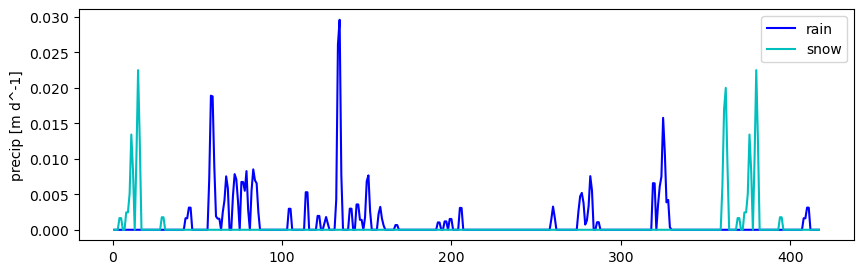

In [7]:
fig, ax = plt.subplots(1,1, figsize=(10,3))

ax.plot(time4plot, rain_precipitation_m_per_d, 'b', label='rain')
ax.plot(time4plot, snow_precipitation_m_per_d, 'c', label='snow')

ax.set_ylabel('precip [m d^-1]')
ax.legend()

In [8]:
# water_flux_left_face_m_per_d and water_flux_right_face_m_per_d
# unit m/d, interpretation: amount of water into the domain, in meter, assuming per surface_area2.
# in another word, viewing all flux (unit m/d) as influx/efflux of surface
water_flux_left_face_m_per_d = data_wb['left face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec
water_flux_right_face_m_per_d = data_wb['right face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec

# unit mol/d
# [note] vars are independent to surface area in this unit
water_flux_left_face_mol_per_d = data_wb['left face flux [mol per time interval]'].iloc[1:] / obs_file_time_interval_vec
water_flux_right_face_mol_per_d = data_wb['right face flux [mol per time interval]'].iloc[1:] / obs_file_time_interval_vec

# water_flux_bottom_face_m_per_d = data_wb['bottom face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec * s_per_d
# water_flux_bottom_face_mol_per_d = data_wb['bottom face flux [mol per time interval]'].iloc[1:] / obs_file_time_interval_vec * s_per_d
# water_flux_front_face_m_per_d = data_wb['front face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec * s_per_d
# water_flux_front_face_mol_per_d = data_wb['front face flux [mol per time interval]'].iloc[1:] / obs_file_time_interval_vec * s_per_d
# water_flux_back_face_m_per_d = data_wb['back face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec * s_per_d
# water_flux_back_face_mol_per_d = data_wb['back face flux [mol per time interval]'].iloc[1:] / obs_file_time_interval_vec * s_per_d

In [9]:
gf = dict()
gf['P'] = data_wb['rain precipitation [m per time interval]'].iloc[1:] / obs_file_time_interval_vec
gf['S'] = data_wb['snow precipitation [m per time interval]'].iloc[1:] / obs_file_time_interval_vec
gf['ET'] = data_wb['evapotranspiration [m per time interval]'].iloc[1:] / obs_file_time_interval_vec
gf['Q'] = data_wb['runoff generation [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec

# minus sign here is to make positive gf['WF_left_sub'] means increase of water content of domain
# WF_left_sub: water flux, left, subsurface
gf['WF_left_sub'] = - data_wb['left face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec
# WF_right_sub: water flux, right, subsurface
gf['WF_right_sub'] = data_wb['right face flux [mol per time interval]'].iloc[1:] / rho_m2 / surface_area2 / obs_file_time_interval_vec 

gf_net = gf['P'] + gf['S'] - gf['ET'] - gf['Q'] + gf['WF_left_sub'] - gf['WF_right_sub']
global_water = (data_wb['canopy water content [mol]'].iloc[1:] + 
                data_wb['snow water content [mol]'].iloc[1:] + 
                data_wb['surface water content [mol]'].iloc[1:] + 
                data_wb['subsurface water content [mol]'].iloc[1:]) / rho_m2 / surface_area2


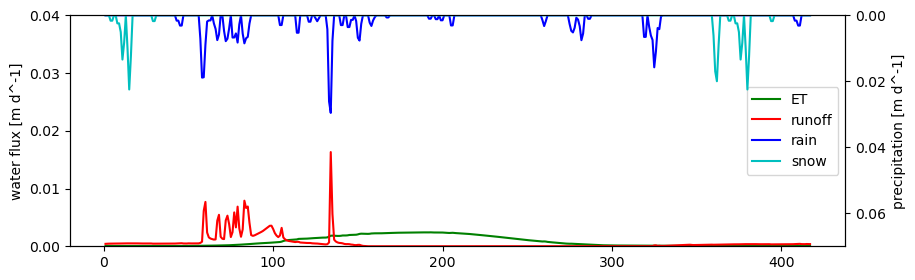

In [10]:
fig, ax = plt.subplots(1,1, figsize=(10,3))

# Plot ET and runoff on the primary y-axis
ax.plot(time4plot, gf['ET'], 'g', label='ET')
ax.plot(time4plot, gf['Q'], 'r', label='runoff')
ax.set_ylabel('water flux [m d^-1]')
ax.set_ylim(0, 0.04)
ax.set_yticks(np.arange(0, 0.041, 0.01))

# Create second y-axis
ax2 = ax.twinx()

# Plot precipitation on the second y-axis
ax2.plot(time4plot, rain_precipitation_m_per_d, 'b', label='rain')
ax2.plot(time4plot, snow_precipitation_m_per_d, 'c', label='snow')
ax2.set_ylabel('precipitation [m d^-1]')
ax2.set_ylim(0, 0.07)
ax2.set_yticks(np.arange(0, 0.07, 0.02))
# Reverse the second y-axis
ax2.invert_yaxis()

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

## load visualization files

In [11]:
# for [subsurface right face], compare darcy_velocity from visualization file and water_flux from observation file
# for [surface right face], it's not comparable. I don't understand surface-velocity.

# based on ATS online documentation, unit of darcy_velocity is m/s, while unit of water_flux is mol/s
# unit conversion: darcy_velocity*surface_area*55000 mol/m3
# noticing: observation file is doing [extensive integral] of water_flux

In [12]:
xlim_preset = (-10,690)
ylim_preset = (940,1120)

In [13]:
vis_surf = xdmf.VisFile(directory=model_dir,
                        domain="surface", 
                        filename="ats_vis_surface_data.h5" , 
                        mesh_filename="ats_vis_surface_mesh.h5")
                        #time_unit='yr')
#select same output as subsurface
#vis_surf.filterIndices(steps)
vis_surf.loadMesh(order=['x','z'])

vis = xdmf.VisFile(directory=model_dir,
                   filename="ats_vis_data.h5", 
                   mesh_filename="ats_vis_mesh.h5")
                   #time_unit='yr')
#select output every 2 days
#vis.filterIndices(steps)
vis.loadMeshPolygons()

In [14]:
print(dir(vis))
print(vis.times)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get', 'centroids', 'close', 'cycles', 'd', 'directory', 'domain', 'filename', 'filterCycles', 'filterIndices', 'filterTimes', 'fname', 'get', 'getArray', 'getMeshPolygons', 'loadMesh', 'loadMeshPolygons', 'loadTimes', 'map', 'mesh_elem_info', 'mesh_filename', 'polygon_coordinates', 'search', 'time_factor', 'time_unit', 'times', 'variable', 'volume']
[0.000000e+00 8.640000e+03 1.728000e+04 ... 3.603744e+07 3.604608e+07
 3.605472e+07]


In [15]:
vis.centroids

array([[   3.4  ,    0.   , 1100.214],
       [   3.4  ,    0.   , 1099.464],
       [   3.4  ,    0.   , 1098.464],
       ...,
       [ 676.6  ,    0.   ,  971.671],
       [ 676.6  ,    0.   ,  971.296],
       [ 676.6  ,    0.   ,  970.796]])

In [16]:
# demo, get var values
varn="total_component_concentration.CH2O(aq)"
step=0
zdata = vis.get(varn, vis.cycles[step])
print(zdata)

[7.56363636e-07 7.56363636e-07 7.56363636e-07 ... 7.56363636e-07
 7.56363636e-07 7.56363636e-07]


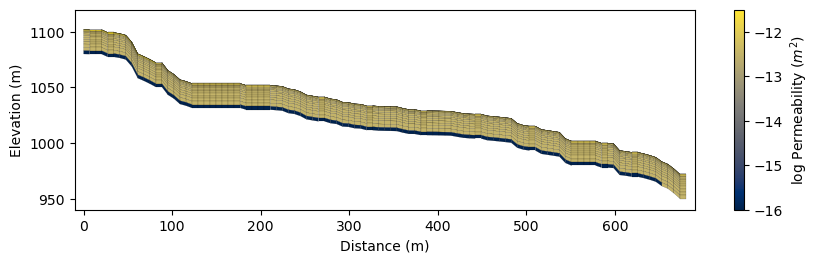

In [17]:
# Plot
fig, ax = plt.subplots(1,1,figsize=(10,2.6),sharex=True)
# norm = mcolors.TwoSlopeNorm(vmin=-16, vcenter=-15, vmax=-11.5)
sat = vis.get("permeability", vis.cycles[0]); sat = np.log10(sat)
poly = vis.getMeshPolygons(cmap='cividis', linewidth=0.1, edgecolor='k')
# sat = vis.get("saturation_liquid", vis.cycles[0]); sat[:] = 0
# poly = vis.getMeshPolygons(cmap='Blues_r', linewidth=0.1, edgecolor='k', norm=norm)
poly.set_array(sat)
poly.set_clim(-16,-11.5)
ax.add_collection(poly)

elev = vis_surf.get('surface-elevation', vis.cycles[-1])
depth = vis_surf.get('surface-ponded_depth', vis.cycles[-1])

ax.plot(vis_surf.centroids[:,0], elev+depth, 'white', linewidth=2, alpha=0)
# ax.axhline(y=0)
plt.colorbar(poly,shrink=1., ax=ax, label = r'$\text{log} \ \text{Permeability} \ (m^2)$')
# ax.plot(0,0)
ax.set(xlabel='Distance (m)', ylabel='Elevation (m)',ylim=ylim_preset, xlim=xlim_preset)

if generate_plots:
    output_filename = '../images/fig1c-hillslope2d.tif'
    fig.savefig(output_filename, dpi=300, pil_kwargs={'compression': 'tiff_lzw'})

In [18]:
# from full_watershed-workflow
# 18 layers in z
dzs_soil = [0.05, 0.05, 0.05, 0.1, 0.25, 0.5, 0.5, 0.5]
dzs_geo = [1., 1., 1.5, 1.5, 2., 2., 2., 3., 3., 3.]
dzs_merged = np.concatenate((dzs_soil, dzs_geo))

print(dzs_merged)

# since width in y-axis is 1m, so areas = dzs_merged

[0.05 0.05 0.05 0.1  0.25 0.5  0.5  0.5  1.   1.   1.5  1.5  2.   2.
 2.   3.   3.   3.  ]


In [19]:
# Assuming your x-coordinates increase from left to right
# Find the maximum x-coordinate of the cell centroids
max_x = np.max(vis.centroids[:, 0])

# Identify the indices of the cells whose centroids have an x-coordinate
# very close to the maximum x-coordinate. This will give you the cells
# on the right boundary. You might need to adjust the tolerance
# depending on the precision of your mesh.
tolerance = 1e-6  # Adjust as needed
right_boundary_cell_indices = np.where(np.abs(vis.centroids[:, 0] - max_x) < tolerance)[0]

# Sort the right boundary cell indices based on their z-centroid
# from largest (top) to smallest (bottom)
sorted_indices = right_boundary_cell_indices[np.argsort(vis.centroids[right_boundary_cell_indices, 2])[::-1]]

print("Original right boundary cell indices:", right_boundary_cell_indices)
print("Sorted right boundary cell indices (top to bottom):", sorted_indices)
print(vis.centroids[sorted_indices, 2])

Original right boundary cell indices: [1697 1698 1699 1700 1701 1702 1703 1704 1705 1706 1707 1793 1794 1795
 1796 1797 1798 1799]
Sorted right boundary cell indices (top to bottom): [1793 1794 1795 1796 1797 1798 1799 1697 1698 1699 1700 1701 1702 1703
 1704 1705 1706 1707]
[972.021 971.971 971.921 971.846 971.671 971.296 970.796 970.296 969.546
 968.546 967.296 965.796 964.046 962.046 960.046 957.546 954.546 951.546]


# plot total concentration over time
- subsurface, unit molS/m3 total_volume
- surface, unit molS/m3 water_volume
- subsurface, unit molS/m3 water_volume

## plot average concentration over time

In [20]:
varn_S = "CH2O(aq)"

In [21]:
varn1_sub = f"total_component_concentration.{varn_S}" # molS/molH2O
varn2_sub = "water_content" # molH2O
varn3_sub = "cell_volume"
#varn4_sub = f"total_component_quantity.{varn_S}"

varn1_srf = f"surface-total_component_concentration.{varn_S}"
varn2_srf = "surface-water_content"

total_quantity_sub     = []
total_water_volume_sub = []
total_bulk_volume_sub  = []

total_quantity_srf     = []
total_water_volume_srf = []

for step in range(len(vis.cycles)):
    zdata1 = vis.get(varn1_sub, vis.cycles[step])
    zdata2 = vis.get(varn2_sub, vis.cycles[step])
    zdata3 = vis.get(varn3_sub, vis.cycles[step])
    total_quantity_sub.append(sum(zdata1*zdata2)) #molS
    total_water_volume_sub.append(sum(zdata2)/rho_m2) #molH2O -> m3 H2O
    total_bulk_volume_sub.append(sum(zdata3))

    zdata1_srf = vis_surf.get(varn1_srf, vis_surf.cycles[step])
    zdata2_srf = vis_surf.get(varn2_srf, vis_surf.cycles[step])
    total_quantity_srf.append(sum(zdata1_srf*zdata2_srf))
    total_water_volume_srf.append(sum(zdata2_srf)/rho_m2)

average_concentration1_sub = np.array(total_quantity_sub)/np.array(total_bulk_volume_sub)
average_concentration2_sub = np.array(total_quantity_sub)/np.array(total_water_volume_sub)
average_saturation_sub     = np.array(total_water_volume_sub)/np.array(total_bulk_volume_sub)
average_concentration2_srf = np.array(total_quantity_srf)/np.array(total_water_volume_srf) 

Text(0.5, 1.0, 'water volume / bulk volume')

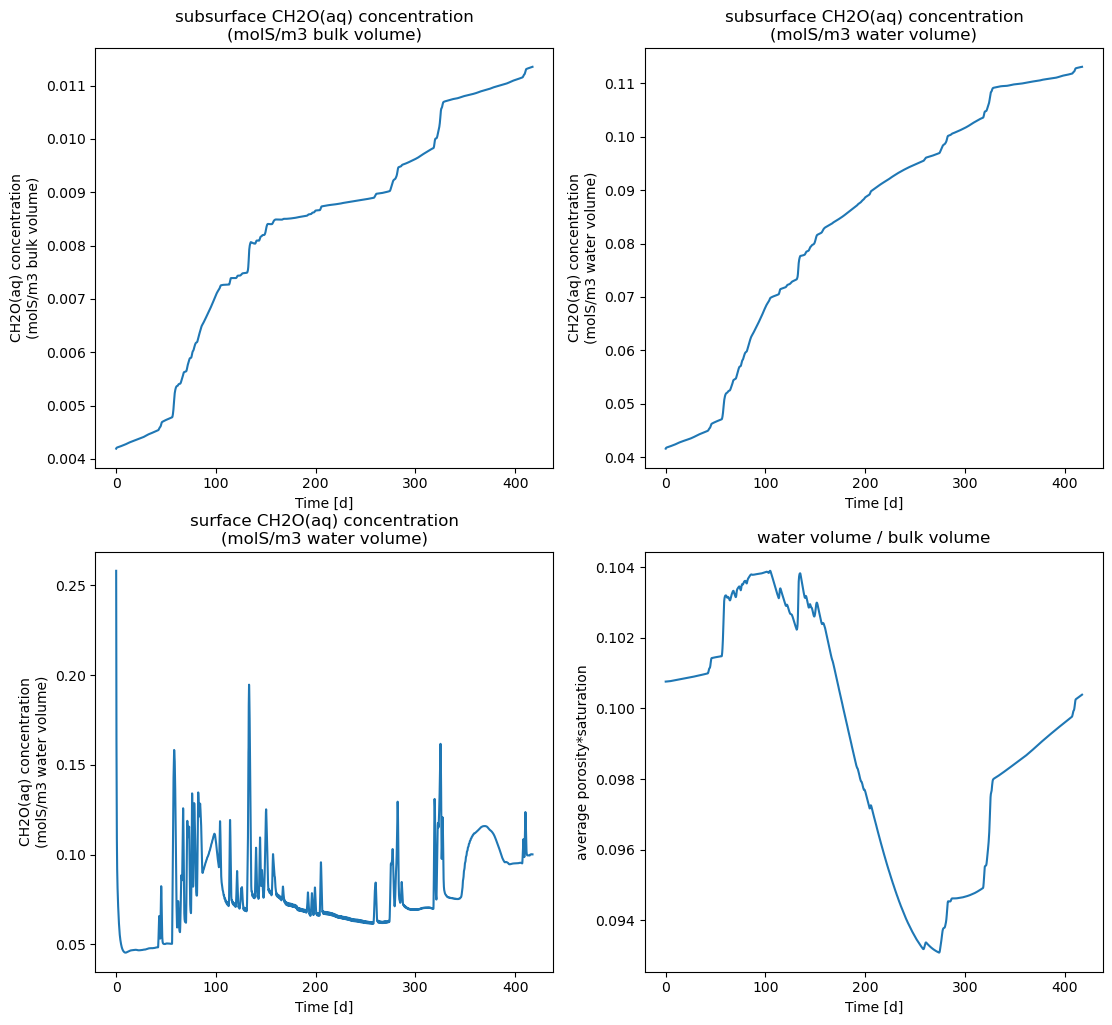

In [22]:
fig, axes = plt.subplots(2,2,figsize=(13,12))
ax = axes.flatten()

ax[0].plot(vis.times/86400, average_concentration1_sub)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel(varn_S + " concentration\n(molS/m3 bulk volume)")
ax[0].set_title("subsurface " + varn_S + " concentration\n(molS/m3 bulk volume)")

ax[1].plot(vis.times/86400, average_concentration2_sub)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel(varn_S + " concentration\n(molS/m3 water volume)")
ax[1].set_title("subsurface " + varn_S + " concentration\n(molS/m3 water volume)")

ax[2].plot(vis_surf.times/86400, average_concentration2_srf)
ax[2].set_xlabel('Time [d]')
ax[2].set_ylabel(varn_S + " concentration\n(molS/m3 water volume)")   
ax[2].set_title("surface " + varn_S + " concentration\n(molS/m3 water volume)")

ax[3].plot(vis.times/86400, average_saturation_sub)
ax[3].set_xlabel('Time [d]')
ax[3].set_ylabel("average porosity*saturation")   
ax[3].set_title("water volume / bulk volume")

In [23]:
def plot_average_concentrations(varn_S: str, i: int, vis, vis_surf, rho_m2, save_data=True):
    """
    Calculates and plots average concentrations and water saturation over time
    for a specified chemical component (varn_S). The resulting figure is
    saved to a file.

    Args:
        varn_S (str): The name of the chemical component (e.g., "CH2O(aq)").
        i (int): An index used for the output filename.
        vis: Visualization object for subsurface data.
        vis_surf: Visualization object for surface data.
        rho_m2 (float): Constant used to convert water mol to water volume m3.
    """
    # Define variable names for visualization data
    varn1_sub = f"total_component_concentration.{varn_S}"
    varn2_sub = "water_content"
    varn3_sub = "cell_volume"
    varn1_srf = f"surface-total_component_concentration.{varn_S}"
    varn2_srf = "surface-water_content"

    # Initialize lists to store time-step-aggregated data
    total_quantity_sub = []
    total_water_volume_sub = []
    total_bulk_volume_sub = []
    total_quantity_srf = []
    total_water_volume_srf = []

    # Loop through all simulation cycles (time steps)
    for step in range(len(vis.cycles)):
        cycle = vis.cycles[step]

        # --- Subsurface Calculations ---
        zdata1 = vis.get(varn1_sub, cycle)  # Concentration (mol/m3 bulk)
        zdata2 = vis.get(varn2_sub, cycle)  # Water content (kg/m3 bulk)
        zdata3 = vis.get(varn3_sub, cycle)  # Cell volume (m3)

        # Quantity (mol): Concentration * Water_Volume_in_cell
        # NOTE: The original code used zdata1 * zdata2, which is (mol/m3_bulk) * (kg/m3_bulk).
        # Assuming zdata1 * zdata2 is a typo and should be the component quantity,
        # which is typically Concentration * Water_Volume.
        # However, following the original logic exactly:
        total_quantity_sub.append(sum(zdata1 * zdata2)) # Following original calculation: sum((mol/m3_bulk) * (kg/m3_bulk))
        # More likely intended: total_quantity_sub.append(sum(vis.get(f"total_component_quantity.{varn_S}", cycle)))

        # Total Water Volume (m3): Sum of (Water Content / rho_m2) * Cell_Volume
        # NOTE: The original code used sum(zdata2)/rho_m2, which is (sum(kg/m3_bulk)) / rho_m2.
        # This only works if all zdata2 values are concentrations in a unit volume cell.
        # Assuming the original calculation is intended:
        total_water_volume_sub.append(sum(zdata2) / rho_m2)

        # Total Bulk Volume (m3): Sum of cell volumes
        total_bulk_volume_sub.append(sum(zdata3))


        # --- Surface Calculations ---
        zdata1_srf = vis_surf.get(varn1_srf, vis_surf.cycles[step]) # Surface concentration (mol/m3 water)
        zdata2_srf = vis_surf.get(varn2_srf, vis_surf.cycles[step]) # Surface water content (kg/m2)

        # Quantity (mol): Concentration * Water_Volume_in_cell
        # NOTE: The original code used zdata1_srf * zdata2_srf, which is (mol/m3_water) * (kg/m2).
        # This appears dimensionally inconsistent for total quantity.
        # Assuming the original calculation is intended:
        total_quantity_srf.append(sum(zdata1_srf * zdata2_srf)) # Following original calculation: sum((mol/m3_water) * (kg/m2))

        # Total Water Volume (m3): Sum of (Surface Water Content / rho_m2)
        # Assuming zdata2_srf is kg/m2 and it covers a certain area to get volume.
        # For 2D surface, kg/m2 / (kg/m3) -> m3/m2 -> m. This calculates a total "depth" or "equivalent volume".
        total_water_volume_srf.append(sum(zdata2_srf) / rho_m2)


    # Convert lists to NumPy arrays for vectorized division
    total_quantity_sub_arr = np.array(total_quantity_sub)
    total_water_volume_sub_arr = np.array(total_water_volume_sub)
    total_bulk_volume_sub_arr = np.array(total_bulk_volume_sub)
    total_quantity_srf_arr = np.array(total_quantity_srf)
    total_water_volume_srf_arr = np.array(total_water_volume_srf)

    # Calculate average concentrations and saturation
    average_concentration1_sub = total_quantity_sub_arr / total_bulk_volume_sub_arr
    average_concentration2_sub = total_quantity_sub_arr / total_water_volume_sub_arr
    average_saturation_sub = total_water_volume_sub_arr / total_bulk_volume_sub_arr
    average_concentration2_srf = total_quantity_srf_arr / total_water_volume_srf_arr

    # Convert time to days (using subsurface time since they're the same)
    time_days = vis.times / 86400
    
    # --- Save Data to CSV ---
    if save_data:
        # Create output directory for data
        data_dir = './data_average_con_overtime'
        if not os.path.exists(data_dir):
            os.makedirs(data_dir)
        
        # Clean variable name for filename
        clean_varn = varn_S.replace('(', '').replace(')', '').replace('.', '_').replace('+', 'plus').replace('-', 'minus')
        
        # Create DataFrame with all time series data (subsurface + surface)
        data_df = pd.DataFrame({
            'time_days': time_days,
            'subsurface_conc_bulk_vol': average_concentration1_sub,
            'subsurface_conc_water_vol': average_concentration2_sub,
            'subsurface_saturation': average_saturation_sub,
            'surface_conc_water_vol': average_concentration2_srf,
            'total_quantity_sub': total_quantity_sub_arr,
            'total_water_volume_sub': total_water_volume_sub_arr,
            'total_bulk_volume_sub': total_bulk_volume_sub_arr,
            'total_quantity_srf': total_quantity_srf_arr,
            'total_water_volume_srf': total_water_volume_srf_arr
        })
        
        # Save combined data
        filename = os.path.join(data_dir, f"timeseries_{i:02d}_{clean_varn}.csv")
        data_df.to_csv(filename, index=False)
        print(f"Time series data saved to {filename}")

    # --- Plotting ---
    fig, axes = plt.subplots(2, 2, figsize=(13, 12))
    ax = axes.flatten()

    # Plot 1: Subsurface Concentration (mol/m3 bulk volume)
    ax[0].plot(vis.times / 86400, average_concentration1_sub)
    ax[0].set_xlabel('Time [d]')
    ax[0].set_ylabel(f"{varn_S} concentration\n(molS/m\u00b3 bulk volume)")
    ax[0].set_title(f"Subsurface {varn_S} concentration\n(molS/m\u00b3 bulk volume)")

    # Plot 2: Subsurface Concentration (mol/m3 water volume)
    ax[1].plot(vis.times / 86400, average_concentration2_sub)
    ax[1].set_xlabel('Time [d]')
    ax[1].set_ylabel(f"{varn_S} concentration\n(molS/m\u00b3 water volume)")
    ax[1].set_title(f"Subsurface {varn_S} concentration\n(molS/m\u00b3 water volume)")

    # Plot 3: Surface Concentration (mol/m3 water volume)
    ax[2].plot(vis_surf.times / 86400, average_concentration2_srf)
    ax[2].set_xlabel('Time [d]')
    ax[2].set_ylabel(f"{varn_S} concentration\n(molS/m\u00b3 water volume)")
    ax[2].set_title(f"Surface {varn_S} concentration\n(molS/m\u00b3 water volume)")

    # Plot 4: Subsurface Average Saturation
    ax[3].plot(vis.times / 86400, average_saturation_sub)
    ax[3].set_xlabel('Time [d]')
    ax[3].set_ylabel("Average porosity * saturation")
    ax[3].set_title("Water volume / Bulk volume")

    plt.tight_layout()

    # --- Saving Plot ---
    output_dir = './figs_average_con_overtime'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    filename = os.path.join(output_dir, f"fig{i}_{varn_S.replace('(', '').replace(')', '').replace('.', '_')}.png")
    fig.savefig(filename)
    plt.close(fig)
    print(f"Plot saved to {filename}")

In [24]:
varn_S_list = ["C5H7O2N(aq)", "CH2O(aq)", "CO2(aq)", "N2(aq)", "NH4+", "NO2-", "NO3-", "O2(aq)"]
varn_tracers_list = ["Tsw", "Tgw", "Tr", "PyC"]
for i, varn_S in enumerate(varn_S_list):
    # 'i' is the index, following the sequence in xml and pflotran input deck
    print(f"Generating plots for: {varn_S} (Index: {i})")
    plot_average_concentrations(varn_S, i+1, vis, vis_surf, rho_m2)


Generating plots for: C5H7O2N(aq) (Index: 0)
Time series data saved to ./data_average_con_overtime/timeseries_01_C5H7O2Naq.csv
Plot saved to ./figs_average_con_overtime/fig1_C5H7O2Naq.png
Generating plots for: CH2O(aq) (Index: 1)
Time series data saved to ./data_average_con_overtime/timeseries_02_CH2Oaq.csv
Plot saved to ./figs_average_con_overtime/fig2_CH2Oaq.png
Generating plots for: CO2(aq) (Index: 2)
Time series data saved to ./data_average_con_overtime/timeseries_03_CO2aq.csv
Plot saved to ./figs_average_con_overtime/fig3_CO2aq.png
Generating plots for: N2(aq) (Index: 3)
Time series data saved to ./data_average_con_overtime/timeseries_04_N2aq.csv
Plot saved to ./figs_average_con_overtime/fig4_N2aq.png
Generating plots for: NH4+ (Index: 4)
Time series data saved to ./data_average_con_overtime/timeseries_05_NH4plus.csv
Plot saved to ./figs_average_con_overtime/fig5_NH4+.png
Generating plots for: NO2- (Index: 5)
Time series data saved to ./data_average_con_overtime/timeseries_06_NO2m

## plot colume averaged concentration over time

## plot soil-layer averaged concentration over time

# Generate animation

In [26]:
xlim_preset = (-10,690)
ylim_preset = (940,1120)

In [27]:
# [to do] 250522
# with the update of "1-full_workflow_OakCreek.ipynb"
# rightx/righty/22.0 below can be loaded from "../data-processed/SF01/m2_SF01_nx100.mat"

# topx and topy are from 1-full_workflow_OakCreek.ipynb
rightx = np.array([  0. ,   6.8,  13.6,  20.4,  27.2,  34. ,  40.8,  47.6,  54.4,  61.2,
  68. ,  74.8,  81.6,  88.4,  95.2, 102. , 108.8, 115.6, 122.4, 129.2,
 136. , 142.8, 149.6, 156.4, 163.2, 170. , 176.8, 183.6, 190.4, 197.2,
 204. , 210.8, 217.6, 224.4, 231.2, 238. , 244.8, 251.6, 258.4, 265.2,
 272. , 278.8, 285.6, 292.4, 299.2, 306. , 312.8, 319.6, 326.4, 333.2,
 340. , 346.8, 353.6, 360.4, 367.2, 374. , 380.8, 387.6, 394.4, 401.2,
 408. , 414.8, 421.6, 428.4, 435.2, 442. , 448.8, 455.6, 462.4, 469.2,
 476. , 482.8, 489.6, 496.4, 503.2, 510. , 516.8, 523.6, 530.4, 537.2,
 544. , 550.8, 557.6, 564.4, 571.2, 578. , 584.8, 591.6, 598.4, 605.2,
 612. , 618.8, 625.6, 632.4, 639.2, 646. , 652.8, 659.6, 666.4, 673.2,
 680. ])
righty = np.array([1102.011, 1101.917, 1101.917, 1101.917, 1099.421, 1099.421, 1098.469,
 1097.036, 1090.794, 1080.269, 1077.915, 1075.28 , 1072.323, 1072.323,
 1065.303, 1061.85 , 1057.017, 1055.526, 1053.547, 1053.547, 1053.547,
 1053.547, 1053.547, 1053.547, 1053.547, 1053.547, 1053.547, 1051.923,
 1051.923, 1051.923, 1051.923, 1051.923, 1051.499, 1051.009, 1048.841,
 1048.111, 1046.253, 1043.301, 1042.374, 1041.46 , 1041.46 , 1039.801,
 1039.101, 1036.813, 1036.478, 1035.245, 1034.981, 1033.532, 1033.532,
 1033.099, 1032.963, 1032.855, 1032.711, 1031.332, 1030.189, 1030.11 ,
 1029.083, 1029.083, 1028.996, 1028.902, 1028.769, 1028.612, 1027.619,
 1026.707, 1026.257, 1026.036, 1026.036, 1024.497, 1024.008, 1023.479,
 1022.879, 1022.248, 1017.741, 1016.066, 1015.267, 1015.267, 1012.226,
 1011.418, 1010.598, 1009.746, 1004.037, 1001.763, 1001.763, 1001.763,
 1001.763, 1001.763,  999.904,  999.904,  999.476,  993.245,  992.59 ,
  991.7  ,  991.7  ,  990.476,  988.979,  987.216,  983.303,  981.041,
  976.897,  972.046,  972.046])
leftx=rightx
lefty=righty-22.0 # due toin 1-full_workflow_OakCreek.ipynb, extrude 22m in depth

In [69]:
# plot Flow Path along the 2D Transect
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib import path as mpath
from matplotlib import patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.colors as colors

from matplotlib.ticker import FixedLocator,FormatStrFormatter, FuncFormatter

In [70]:
def get_var_lim(vis, varn, step_range):
    global_zmin = float('inf')
    global_zmax = float('-inf')
    
    for step in step_range:
        zdata = vis.get(varn, vis.cycles[step])
        tmp_zmin, tmp_zmax = zdata.min(), zdata.max()
        global_zmin = min(global_zmin, tmp_zmin)
        global_zmax = max(global_zmax, tmp_zmax)
        
    return global_zmin, global_zmax

def get_var_lim_percentile(vis, varn, step_range, lower_percentile=5, upper_percentile=95, scale_factor=1.0):
    all_data = []
    for step in step_range:
        zdata = vis.get(varn, vis.cycles[step])
        zdata = zdata * scale_factor
        all_data.append(zdata.flatten())
    
    all_data = np.concatenate(all_data)
    global_zmin = np.percentile(all_data, lower_percentile)
    global_zmax = np.percentile(all_data, upper_percentile)
    
    return global_zmin, global_zmax

# Usage
#zmin, zmax = get_var_lim_percentile(vis, varn, step_range, lower_percentile=1, upper_percentile=99)

def create_custom_bounds(zmin, zmax, n_lower=70, n_upper=30):
    """Create more levels for lower values, fewer for upper values"""
    # 70% of color levels for lower 50% of data range
    mid_value = zmin + 0.5 * (zmax - zmin)
    
    lower_bounds = np.linspace(zmin, mid_value, n_lower)
    upper_bounds = np.linspace(mid_value, zmax, n_upper)[1:]  # Exclude duplicate mid_value
    
    return np.concatenate([lower_bounds, upper_bounds])

# Usage
# bounds = create_custom_bounds(zlim[0], zlim[1])
# cont = ax.tricontourf(xdata, ydata, zdata, levels=bounds, cmap=cmap)

In [71]:
def create_tricontour_plot(step, vis,varn, clim, log=False,
                           cmap='jet', zlim=None, showtime=True, 
                           ax=None, scale_factor=1.0,
                           bounds_custom=None):
    # Get the x, y, and z data for the tricontour plot
    xdata = vis.centroids[:, 0]
    ydata = vis.centroids[:, 2]
    zdata = vis.get(varn, vis.cycles[step])# can do unit conversion here, *32*1000*55
    zdata = zdata*scale_factor
    zlim  = zlim*scale_factor
    
    if log: 
        zdata = np.log10(zdata)
        zlim  = np.log10(zlim)
    #if np.any(zdata>7.5):
        # Add a small positive value to zdata to avoid zeros or negative values
     #   zdata[zdata>7.5] = 7.5

    vertices = np.vstack([np.concatenate([leftx, rightx[::-1]]), np.concatenate([lefty, righty[::-1]])]).T
    poly_codes = [mpath.Path.MOVETO] + (len(vertices) - 1) * [mpath.Path.LINETO]
    path = mpath.Path(vertices, poly_codes)
    clip_patch = mpatches.PathPatch(path, facecolor='none', edgecolor='none')
    ax.add_patch(clip_patch)

    # Create the tricontour plot with the current clipping patch
    # the user can changed the last number to get different contour like from 10 to 100
    if bounds_custom is None:
        bounds=np.linspace(zlim[0],zlim[1]*1.001,100)
    else:
        bounds=bounds_custom
    norm = mcolors.BoundaryNorm(bounds, ncolors=256)
    #cont = ax.tricontourf(xdata, ydata, zdata, vmax=zlim[1], vmin=zlim[0],levels=bounds, cmap=cmap)
    cont = ax.tricontourf(xdata, ydata, zdata, 
                     levels=bounds, 
                     cmap=cmap,
                     norm=norm,
                     extend='both')
    print(zlim)

    for col in cont.collections:
        col.set_clip_path(clip_patch.get_path(), clip_patch.get_transform())
    
    if showtime:
        # days = step // 24  # calculate the number of days
        # time = step % 24  # calculate the time within a day
        # time_str = f'{time:02d}:00'  # format the time as 'hh:00'
        days = step
        ax.text(0.8, 0.95, 'Day {}'.format(days), transform=ax.transAxes, fontsize=12,
                fontweight='bold', va='top', ha='left')

    return cont, ax

# ## usage of this function
# # Call the function
# cont, ax = create_tricontour_plot(step, vis, varn="saturation_liquid", log=False,
#                                   clim=[0,1], cmap='bwr_r', zlim=zlim,
#                                   showtime=False, ax=ax)

# # Configure colorbar
# cbar=fig.colorbar(cont, ax=ax, label='Saturation', pad=0.02)
# cbar.ax.yaxis.set_major_locator(FixedLocator([zlim[0],0.25,0.50,0.75, zlim[1]]))
# cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f')) # Adjust as needed
# cbar.ax.yaxis.set_minor_locator(FixedLocator([0.25,0.50,0.75]))
# cbar.ax.tick_params(labelsize=10) # Adjust 10 as needed

# # Configure axis
# ax.set_xlim(xlim_preset)
# ax.set_xticks(np.arange(0, 680, 100))
# ax.set_ylim(ylim_preset)
# ax.set_yticks(np.arange(950, 1101, 50))
# ax.tick_params(axis='both', which='major', labelsize=10) # Adjust 10 as needed

In [72]:
print(dir(vis))
print(len(vis.cycles))
print(vis.times)
print(vis.time_unit)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get', 'centroids', 'close', 'cycles', 'd', 'directory', 'domain', 'filename', 'filterCycles', 'filterIndices', 'filterTimes', 'fname', 'get', 'getArray', 'getMeshPolygons', 'loadMesh', 'loadMeshPolygons', 'loadTimes', 'map', 'mesh_elem_info', 'mesh_filename', 'polygon_coordinates', 'search', 'time_factor', 'time_unit', 'times', 'variable', 'volume']
3651
[0.000000e+00 8.640000e+04 1.728000e+05 ... 3.151872e+08 3.152736e+08
 3.153600e+08]
yr


## single frame plot

In [73]:
step=3000
vis_time_value = vis.times[step]/s_per_d
print(vis_time_value)

3000.0


In [74]:
print(len(vis.times))
print(vis_time_value)

3651
3000.0


In [78]:
zmin, zmax = get_var_lim_percentile(vis=vis, 
                                    varn="total_component_concentration.CH2O(aq)",
                                    step_range=range(3285,3650), 
                                    lower_percentile=0, upper_percentile=100)
zmax = 0.5/rho_m2
print([zmin*rho_m2, zmax*rho_m2]) # unit molS/molH2O -> molS/m3 H2O
print([np.log10(zmin*rho_m2),np.log10(zmax*rho_m2)]) # values in the plot
n_ticks = 6
log_tick_positions = np.linspace(np.log10(zmin*rho_m2),np.log10(zmax*rho_m2), n_ticks)
original_values = 10**log_tick_positions

print(log_tick_positions)
print(original_values)

[0.06840469360219728, 0.5]
[-1.1649140980518118, -0.3010299956639812]
[-1.1649141  -0.99213728 -0.81936046 -0.64658364 -0.47380682 -0.30103   ]
[0.06840469 0.10182695 0.15157918 0.22564014 0.33588699 0.5       ]


[0. 1.]
[-1.1649141 -0.30103  ]


/tmp/ipykernel_1263495/2899370743.py:40: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


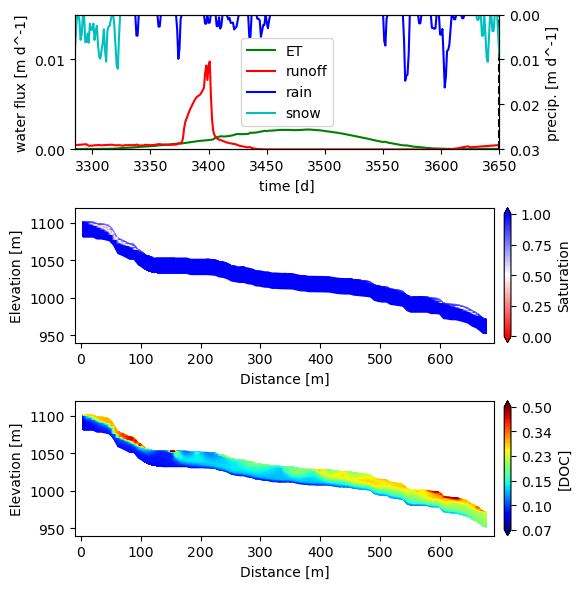

In [89]:
step=3650
#vis_time_value = vis.times[step]/s_per_d

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(3, 2, width_ratios=[80,1], height_ratios=[1, 1, 1])

# Left Column -- 1/3 Row
ax1 = fig.add_subplot(gs[0, 0]) # Use gridspec for the first subplot
ax1.plot(time4plot, gf['ET'], 'g', label='ET')
ax1.plot(time4plot, gf['Q'], 'r', label='runoff')
ax1.set_xlabel('time [d]')
ax1.set_ylabel('water flux [m d^-1]')
ax1.set_ylim(0, 0.015)
ax1.set_yticks(np.arange(0, 0.015, 0.01))

ax1b = ax1.twinx()
ax1b.plot(time4plot, rain_precipitation_m_per_d, 'b', label='rain')
ax1b.plot(time4plot, snow_precipitation_m_per_d, 'c', label='snow')
ax1b.set_ylabel('precip. [m d^-1]')
ax1b.set_ylim(0, 0.03)
# Reverse the second y-axis
ax1b.invert_yaxis()
ax1b.set_yticks(np.arange(0, 0.031, 0.01))
# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center")
ax1.set_xlim(3285,3650)
ax1b.set_xlim(3285,3650)
# Add vertical line - NO LABEL HERE
ax1.axvline(x=step, color='k', linestyle='--', linewidth=1.5)

# Left Column -- 2/3 Row
ax2 = fig.add_subplot(gs[1, :])
cont, ax = create_tricontour_plot(step, vis, varn="saturation_liquid", log=False,
                                  clim=[0,1], cmap='bwr_r', zlim=np.array([0,1]), showtime=False,
                                  ax=ax2)
cbar=fig.colorbar(cont, ax=ax, label='Saturation', pad=0.02)
cbar.ax.yaxis.set_major_locator(FixedLocator([0,0.25,0.50,0.75, 1]))
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f')) # Adjust as needed
cbar.ax.yaxis.set_minor_locator(FixedLocator([0.25,0.50,0.75]))
cbar.ax.tick_params(labelsize=10) # Adjust 10 as needed
ax.set_xlim(xlim_preset)
ax.set_xticks(np.arange(0, 680, 100))
ax.set_ylim(ylim_preset)
ax.set_yticks(np.arange(950, 1101, 50))
ax.tick_params(axis='both', which='major', labelsize=10) # Adjust 10 as needed
ax2.set_xlabel('Distance [m]')
ax2.set_ylabel('Elevation [m]')

# Right Column -- 3/3 Row
ax3 = fig.add_subplot(gs[2, :])
cont, ax = create_tricontour_plot(step, vis, varn="total_component_concentration.CH2O(aq)", log=True,
                                  clim=[0,1], cmap='jet', zlim=np.array([zmin, zmax]), scale_factor=rho_m2,
                                  showtime=False, ax=ax3)
cbar=fig.colorbar(cont, ax=ax, label='[DOC]', pad=0.02)
cbar.set_ticks(log_tick_positions)
cbar.set_ticklabels([f'{val:.2f}' for val in original_values])
cbar.ax.minorticks_off()

#cbar.ax.yaxis.set_major_locator(FixedLocator([0, 0.5 ,1.0]))
#cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f')) # Adjust as needed
#cbar.ax.yaxis.set_minor_locator(FixedLocator([0.25,0.75]))
cbar.ax.tick_params(labelsize=10) # Adjust 10 as needed
ax.set_xlim(xlim_preset)
ax.set_xticks(np.arange(0, 680, 100))
ax.set_ylim(ylim_preset)
ax.set_yticks(np.arange(950, 1101, 50))
ax.tick_params(axis='both', which='major', labelsize=10) # Adjust 10 as needed
ax2.set_xlabel('Distance [m]')
ax2.set_ylabel('Elevation [m]')
ax3.set_xlabel('Distance [m]')
ax3.set_ylabel('Elevation [m]')

 
# Adjust overall layout to prevent labels/titles overlapping
plt.tight_layout() # This is generally good practice

# # Adjust overall subplot parameters for alignment and spacing
# plt.subplots_adjust(
#     left=0.05,    # Adjust left boundary
#     right=0.95,   # Adjust right boundary (giving space for colorbar)
#     bottom=0.08,  # Adjust bottom boundary for x-labels
#     top=0.95,     # Adjust top boundary for titles
#     wspace=0.15   # Horizontal space between columns
# )

## animation

In [91]:
# --- Create output directory if it doesn't exist ---
output_folder = './images'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created directory: {output_folder}")
else:
    print(f"Directory already exists: {output_folder}")

# --- Initialize frame counter ---
frame_counter = 0
# --- Loop through steps and save figures ---
for step in range(3650-365, 3650,1): # Loop from 0 up to and including 365
    print(f"Generating figure for step {step}...")

    # Ensure the step is a valid index for vis.times
    if step >= len(vis.times):
        print(f"Warning: step {step} is out of bounds for vis.times. Skipping.")
        continue
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(3, 2, width_ratios=[80,1], height_ratios=[1, 1, 1])
    
    # Left Column -- 1/3 Row
    ax1 = fig.add_subplot(gs[0, 0]) # Use gridspec for the first subplot
    ax1.plot(time4plot, gf['ET'], 'g', label='ET')
    ax1.plot(time4plot, gf['Q'], 'r', label='runoff')
    ax1.set_xlabel('time [d]')
    ax1.set_ylabel('water flux [m d^-1]')
    ax1.set_ylim(0, 0.015)
    ax1.set_yticks(np.arange(0, 0.015, 0.01))
    
    ax1b = ax1.twinx()
    ax1b.plot(time4plot, rain_precipitation_m_per_d, 'b', label='rain')
    ax1b.plot(time4plot, snow_precipitation_m_per_d, 'c', label='snow')
    ax1b.set_ylabel('precip. [m d^-1]')
    ax1b.set_ylim(0, 0.03)
    # Reverse the second y-axis
    ax1b.invert_yaxis()
    ax1b.set_yticks(np.arange(0, 0.031, 0.01))
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center")
    ax1.set_xlim(3285,3650)
    ax1b.set_xlim(3285,3650)
    # Add vertical line - NO LABEL HERE
    ax1.axvline(x=step, color='k', linestyle='--', linewidth=1.5)
    
    # Left Column -- 2/3 Row
    ax2 = fig.add_subplot(gs[1, :])
    cont, ax = create_tricontour_plot(step, vis, varn="saturation_liquid", log=False,
                                      clim=[0,1], cmap='bwr_r', zlim=np.array([0,1]), showtime=False,
                                      ax=ax2)
    cbar=fig.colorbar(cont, ax=ax, label='Saturation', pad=0.02)
    cbar.ax.yaxis.set_major_locator(FixedLocator([0,0.25,0.50,0.75, 1]))
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f')) # Adjust as needed
    cbar.ax.yaxis.set_minor_locator(FixedLocator([0.25,0.50,0.75]))
    cbar.ax.tick_params(labelsize=10) # Adjust 10 as needed
    ax.set_xlim(xlim_preset)
    ax.set_xticks(np.arange(0, 680, 100))
    ax.set_ylim(ylim_preset)
    ax.set_yticks(np.arange(950, 1101, 50))
    ax.tick_params(axis='both', which='major', labelsize=10) # Adjust 10 as needed
    ax2.set_xlabel('Distance [m]')
    ax2.set_ylabel('Elevation [m]')
    
    # Right Column -- 3/3 Row
    ax3 = fig.add_subplot(gs[2, :])
    cont, ax = create_tricontour_plot(step, vis, varn="total_component_concentration.CH2O(aq)", log=True,
                                      clim=[0,1], cmap='jet', zlim=np.array([zmin, zmax]), scale_factor=rho_m2,
                                      showtime=False, ax=ax3)
    cbar=fig.colorbar(cont, ax=ax, label='[DOC]', pad=0.02)
    cbar.set_ticks(log_tick_positions)
    cbar.set_ticklabels([f'{val:.2f}' for val in original_values])
    cbar.ax.minorticks_off()
    
    #cbar.ax.yaxis.set_major_locator(FixedLocator([0, 0.5 ,1.0]))
    #cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f')) # Adjust as needed
    #cbar.ax.yaxis.set_minor_locator(FixedLocator([0.25,0.75]))
    cbar.ax.tick_params(labelsize=10) # Adjust 10 as needed
    ax.set_xlim(xlim_preset)
    ax.set_xticks(np.arange(0, 680, 100))
    ax.set_ylim(ylim_preset)
    ax.set_yticks(np.arange(950, 1101, 50))
    ax.tick_params(axis='both', which='major', labelsize=10) # Adjust 10 as needed
    ax2.set_xlabel('Distance [m]')
    ax2.set_ylabel('Elevation [m]')
    ax3.set_xlabel('Distance [m]')
    ax3.set_ylabel('Elevation [m]')
    
     
    # Adjust overall layout to prevent labels/titles overlapping
    plt.tight_layout() # This is generally good practice
    
    # # Adjust overall subplot parameters for alignment and spacing
    # plt.subplots_adjust(
    #     left=0.05,    # Adjust left boundary
    #     right=0.95,   # Adjust right boundary (giving space for colorbar)
    #     bottom=0.08,  # Adjust bottom boundary for x-labels
    #     top=0.95,     # Adjust top boundary for titles
    #     wspace=0.15   # Horizontal space between columns
    # )
    # Save the figure
    # Use zero-padding for the filename to ensure correct sorting for animation
    #filename = os.path.join(output_folder, f'frame_{frame_counter:04d}.png') # e.g., frame_0000.png, frame_0001.png
    #plt.savefig(filename, dpi=150, bbox_inches='tight') # dpi can be adjusted for quality
    filename = os.path.join(output_folder, f'frame_{frame_counter:04d}.jpg')
    plt.savefig(filename, dpi=150)
    plt.close(fig) # Close the figure to free up memory
    frame_counter += 1

print(f"Generated {step + 1} figures in '{output_folder}' directory.")
print("You can now use a tool like FFmpeg to create an animation:")
#print(f"ffmpeg -framerate 10 -i {output_folder}/frame_%04d.png -c:v libx264 -r 30 -pix_fmt yuv420p -vf \"scale=1980:962\" output_animation.mp4")

Directory already exists: ./images
Generating figure for step 3285...
[0. 1.]
[-1.1649141 -0.30103  ]


/tmp/ipykernel_1263495/2899370743.py:40: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


Generating figure for step 3286...
[0. 1.]
[-1.1649141 -0.30103  ]


/tmp/ipykernel_1263495/2899370743.py:40: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


Generating figure for step 3287...
[0. 1.]
[-1.1649141 -0.30103  ]


...

Generating figure for step 3648...
[0. 1.]
[-1.1649141 -0.30103  ]


/tmp/ipykernel_1263495/2899370743.py:40: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


Generating figure for step 3649...
[0. 1.]
[-1.1649141 -0.30103  ]


/tmp/ipykernel_1263495/2899370743.py:40: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


Generated 3650 figures in './images' directory.
You can now use a tool like FFmpeg to create an animation:


In [92]:
import sys
import os

home_dir = os.path.expanduser("~")
my_utils_path = os.path.join(home_dir, 'my_utils')
if my_utils_path not in sys.path:
    sys.path.append(my_utils_path)

from viz import make_gif_ffmpeg

generate_animation=True
if generate_animation == True:
    make_gif_ffmpeg(image_folder='./images', fps=10, input_jpg_fname='frame_%04d.jpg', output_gif_fname='CH2O_365d.gif')

ffmpeg version 3.4.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with gcc 7 (SUSE Linux)
  configuration: --prefix=/usr --libdir=/usr/lib64 --shlibdir=/usr/lib64 --incdir=/usr/include/ffmpeg --extra-cflags='-fmessage-length=0 -grecord-gcc-switches -O2 -Wall -D_FORTIFY_SOURCE=2 -fstack-protector-strong -funwind-tables -fasynchronous-unwind-tables -fstack-clash-protection -g' --optflags='-fmessage-length=0 -grecord-gcc-switches -O2 -Wall -D_FORTIFY_SOURCE=2 -fstack-protector-strong -funwind-tables -fasynchronous-unwind-tables -fstack-clash-protection -g' --disable-htmlpages --enable-pic --disable-stripping --enable-shared --disable-static --enable-gpl --disable-openssl --enable-avresample --enable-libcdio --enable-gnutls --enable-ladspa --disable-cuda --disable-cuvid --enable-libass --enable-libbluray --enable-libcelt --enable-libcdio --enable-libdc1394 --enable-libfreetype --enable-libgsm --enable-libmp3lame --enable-libopenjpeg --enable-libopus --enable-libpulse --enable-libs

GIF successfully created: CH2O_365d.gif


frame=  365 fps=139 q=-0.0 Lsize=    2449kB time=00:00:36.41 bitrate= 550.9kbits/s speed=13.8x    
video:2445kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.148626%


# Tutorial about visualization data

In [17]:
varn = "darcy_velocity.0"
all_steps_sum = []

for step in range(len(vis.cycles)):
    zdata = vis.get(varn, vis.cycles[step])

    # Multiply the zdata at the sorted right boundary indices by the merged array
    # Ensure that the lengths are compatible for element-wise multiplication
    if len(zdata[sorted_indices]) == len(dzs_merged):
        multiplied_data = zdata[sorted_indices] * dzs_merged
        step_sum = np.sum(multiplied_data)
        all_steps_sum.append(step_sum)
    else:
        print(f"Warning: Length mismatch between zdata[sorted_indices] ({len(zdata[sorted_indices])}) and merged_array ({len(merged_array)}). Skipping multiplication and summation for this step.")
        all_steps_sum.append(None) # Or some other indicator of failure

#print("\nSum of multiplied data for all steps:", all_steps_sum)

all_steps_sum_array = np.array(all_steps_sum)

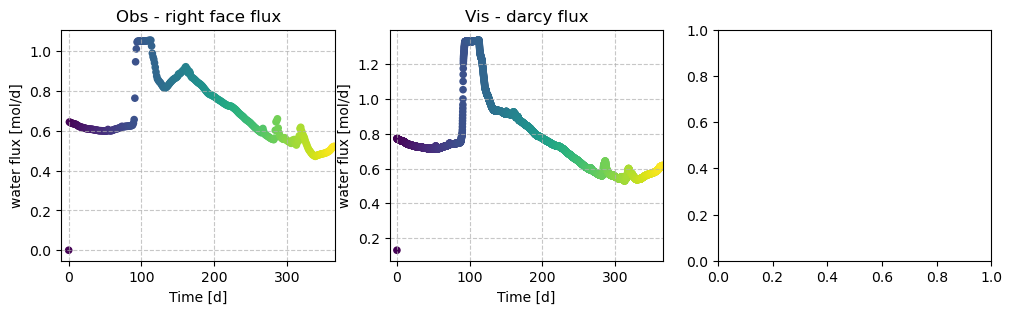

In [22]:
# all_steps_sum is in m3/s
# compare with data_wb['right face flux'] in mol/(time interval)

xmin = -10
xmax = 366

# Create the figure with subplots
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

# Get the time data for coloring
time_data_obs = data_wb['time [d]']
time_data_vis = vis.times/86400

# Plot 1: water_flux from observation file
ax[0].scatter(time_data_obs, data_wb['right face flux [mol per time interval]']/86400/obs_file_time_interval_vec, 
           c=time_data_obs, cmap='viridis', s=20)
ax[0].set_xlabel('Time [d]')
ax[0].set_ylabel('water flux [mol/d]')
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[0].set_xlim(xmin, xmax)
ax[0].set_title('Obs - right face flux')

# Plot 2: flux based on darcy_velocity from visualization file
ax[1].scatter(time_data_vis, all_steps_sum_array*rho_m2, 
           c=time_data_vis, cmap='viridis', s=20)
ax[1].set_xlabel('Time [d]')
ax[1].set_ylabel('water flux [mol/d]')
ax[1].grid(True, linestyle='--', alpha=0.7)
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].set_xlim(xmin, xmax)
ax[1].set_title('Vis - darcy flux')

# Plot 3: 1-1 plot
if vis_file_time_interval==obs_file_time_interval:
    ax[2].scatter(data_wb['right face flux [mol per time interval]']/obs_file_time_interval, all_steps_sum_array*rho_m2*86400,
                  c=time_data_obs, cmap='viridis', marker='.', s=50)
    ax[2].set_xlabel('Obs - water flux')
    ax[2].set_ylabel('Vis - darcy velocity * molar density')
    ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    x_vals = np.linspace(0, 1.3e5, 100)
    ax[2].plot(x_vals, x_vals, 'k--')
    ax[2].set_title('Vis - Obs 1-1 Plot')
    tmp_ratio = (all_steps_sum_array*rho_m2*86400)/(data_wb['right face flux [mol per time interval]']/obs_file_time_interval)
    print("ratio of darcy_vel based water flux vs water flux from vis file: ", tmp_ratio.iloc[-1])

## total_component_concentration and total_component_quantity

In [40]:
varn_S = "CH2O(aq)"

step=100

varn1  = f"total_component_concentration.{varn_S}"
zdata1 = vis.get(varn1, vis.cycles[step])
varn2  = f"total_component_quantity.{varn_S}"
zdata2 = vis.get(varn2, vis.cycles[step])
varn3 = "water_content"
zdata3 = vis.get(varn3, vis.cycles[step])

Text(0.5, 1.0, '1-1 plot')

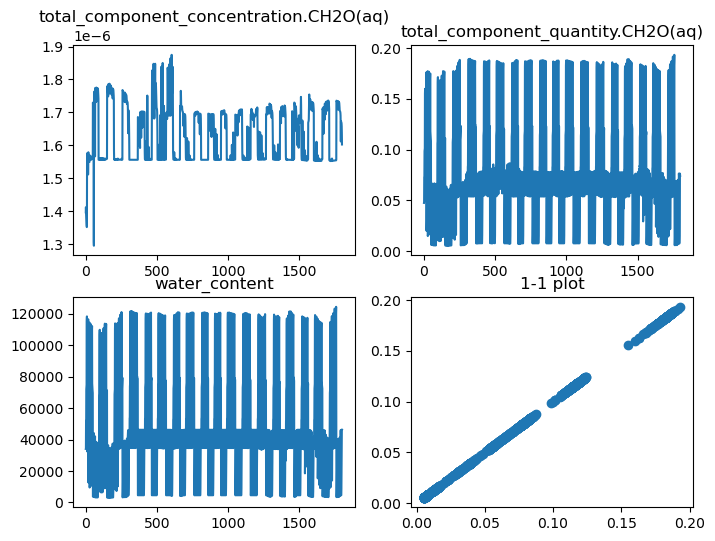

In [44]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
ax = axes.flatten()

ax[0].plot(zdata1)
ax[0].set_title(varn1)

ax[1].plot(zdata2)
ax[1].set_title(varn2)

ax[2].plot(zdata3)
ax[2].set_title(varn3)

ax[3].scatter(zdata2, zdata1*zdata3)
ax[3].set_title("1-1 plot")

In [55]:
varn_S = "CH2O(aq)"

step=100

varn1  = f"surface-total_component_concentration.{varn_S}"
zdata1 = vis_surf.get(varn1, vis_surf.cycles[step])
varn2  = f"surface-total_component_quantity.{varn_S}"
zdata2 = vis_surf.get(varn2, vis_surf.cycles[step])
varn3 = "surface-water_content"
zdata3 = vis_surf.get(varn3, vis_surf.cycles[step])

Text(0.5, 1.0, '1-1 plot')

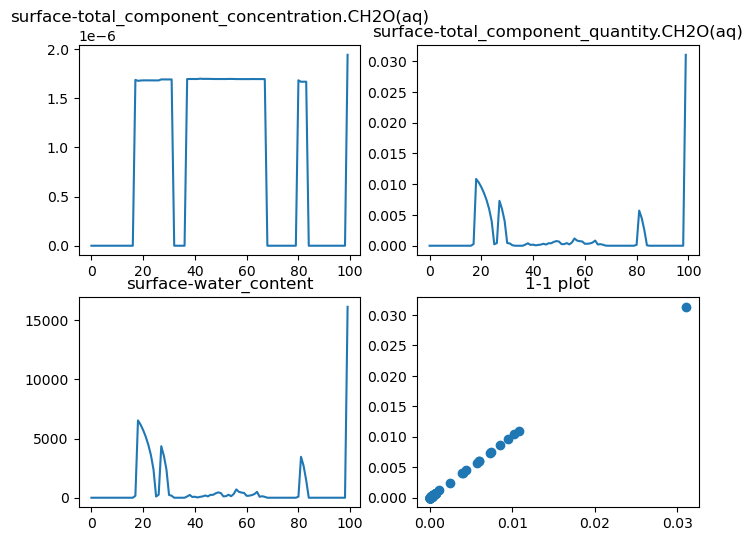

In [56]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
ax = axes.flatten()

ax[0].plot(zdata1)
ax[0].set_title(varn1)

ax[1].plot(zdata2)
ax[1].set_title(varn2)

ax[2].plot(zdata3)
ax[2].set_title(varn3)

ax[3].scatter(zdata2, zdata1*zdata3)
ax[3].set_title("1-1 plot")

## cell_volume and total bulk volume

In [51]:
print("total soil thickness is: " + str(sum(dzs_merged)))
varn  = "cell_volume"
zdata = vis.get(varn, vis.cycles[step])
total_volume = sum(zdata)
total_volume_expected = 680*sum(dzs_merged)

print(total_volume)
print(total_volume_expected)
# therefore, unit of cell_volume is m^3

total soil thickness is: 22.0
14959.999999999889
14960.0


## porosity, water content, and saturation

[55000. 55000. 55000. ... 55000. 55000. 55000.]


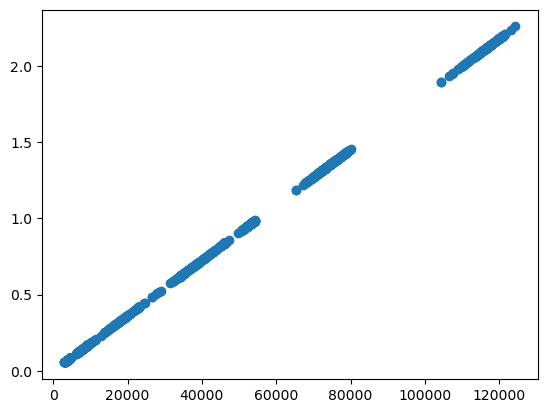

In [54]:
varn1  = "cell_volume"
zdata1 = vis.get(varn1, vis.cycles[step])
varn2  = "porosity"
zdata2 = vis.get(varn2, vis.cycles[step])
varn3  = "water_content"
zdata3 = vis.get(varn3, vis.cycles[step])
varn4  = "saturation_liquid"
zdata4 = vis.get(varn4, vis.cycles[step])

# void_volume = cell_volume * porosity
void_volume = zdata1*zdata2
# water_volume = void_volume * saturation_liquid
water_volume = void_volume*zdata4

plt.scatter(zdata3, water_volume)

print(zdata3/water_volume)